In [1]:
import pandas as pd
import os
import globals as gl
import matplotlib.pyplot as plt
import PcmPy as pcm
import numpy as np 

Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


In [2]:
snS = [102, 103, 104, 106, 107]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

loading subj102
loading subj103
loading subj104
loading subj106
loading subj107


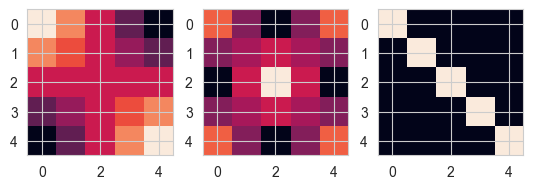

In [4]:
C = pcm.centering(5)

v_cue =  C @ np.array([-2, -1, 0, 1, 2]) 
v_cert = C @ np.array([0, 1, 2, 1, 0])

G_cue = np.outer(v_cue, v_cue)

G_cert = np.outer(v_cert, v_cert)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(G_cue)
axs[1].imshow(G_cert)
axs[2].imshow(np.eye(5))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating voxel activity for two conditions: index and ring finger stimulation
n_voxels = 200  # Assume we have 200 voxels
voxels_index = np.random.rand(n_voxels)  # Random initial activation pattern for index
voxels_ring = np.random.rand(n_voxels)  # Random initial activation pattern for ring

# Normalize voxel activity to sum to 1 (simulating probability distribution encoding)
voxels_index /= np.sum(voxels_index)
voxels_ring /= np.sum(voxels_ring)

# Define priors: initially balanced, then biased toward the index finger
cues = np.linspace(0, 1, 5)  # Prior shifts from 50% index to 90% index

# Define the actual stimulated finger (0 = ring, 1 = index)
stimFinger = [0, 1]  # Randomly select actual stimulus

# Define likelihoods (how sensory evidence modifies voxel activity)
likelihood_strength = 0.7  # Controls how much sensory evidence influences voxel activity
if stimulated_finger == 1:
    likelihood = likelihood_strength * voxels_index + (1 - likelihood_strength) * voxels_ring
else:
    likelihood = likelihood_strength * voxels_ring + (1 - likelihood_strength) * voxels_index

# Store posterior voxel activity patterns
voxel_patterns = []

for cueI in cues:
    for stimF in stimFinger:
        cueR = 1 - cueI  # Complementary probability
        posterior_voxels = cueI * voxels_index + cueR * voxels_ring  # Bayesian prior
        posterior_voxels = posterior_voxels * (1 - likelihood_strength) + likelihood * likelihood_strength  # Combine with sensory evidence
        voxel_patterns.append(posterior_voxels)

# Convert to numpy array for easier visualization
voxel_patterns = np.array(voxel_patterns)

# Plot voxel activity patterns as the prior shifts
plt.figure(figsize=(10, 6))
for i, prior_index in enumerate(priors):
    plt.plot(voxel_patterns[i], label=f"Prior Index: {prior_index:.1f}")

plt.xlabel("Voxel Index")
plt.ylabel("Voxel Activity")
plt.title("Effect of Prior Shift and Actual Stimulus on Voxel Activity Encoding")
plt.legend()
plt.show()

# Print the actual stimulated finger
print(f"Actual Stimulated Finger: {'Index' if stimulated_finger == 1 else 'Ring'}")


In [70]:
import sys

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import Functional_Fusion.atlas_map as am
import nitools as nt
import os
import globals as gl
import numpy as np

experiment = 'smp2'

atlas_dir = '/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion/Functional_Fusion/Atlases/tpl-fs32k/'

sn  = 107

# Define the region, get only left hemisphere
atlas,_ = am.get_atlas('fs32k')

ncol = 1
data_out = np.zeros((32492, ncol))  # populate this with data from each tessel

ntessels = 362

for i in range(ntessels):
# i = 3
    print(f'processing tessel #{i}')

    atlas_left = atlas.get_hemisphere(0)
    subatlas = atlas_left.get_subatlas_image(os.path.join(atlas_dir, f'Icosahedron{ntessels}.L.label.gii'), i)

    glm_dir = os.path.join(gl.baseDir, experiment ,'glm12')
    surf_dir = os.path.join(gl.baseDir, experiment, 'surfaceWB')
    white = surf_dir + f'/subj{sn}/subj{sn}.L.white.32k.surf.gii' # Individual white surface
    pial = surf_dir + f'/subj{sn}/subj{sn}.L.pial.32k.surf.gii'   # Invividual pial surface
    mask = glm_dir + f'/subj{sn}/mask.nii'                      # Mask in functional space
    amap = am.AtlasMapSurf(subatlas.vertex[0],white,pial,mask) # Atlas map
    amap.build()

    dnames = [os.path.join(glm_dir, f'subj{sn}', f'beta_{i+1:04d}.nii') for i in range(10)]

    X = amap.extract_data_native(dnames)

    Y = np.nanmean(X)

    data_out[subatlas.vertex[0]] = Y

processing tessel #0


/tmp/ipykernel_27782/2388706503.py:47: RuntimeWarning: Mean of empty slice
  Y = np.nanmean(X)


processing tessel #1
processing tessel #2
processing tessel #3
processing tessel #4
processing tessel #5
processing tessel #6
processing tessel #7
processing tessel #8
processing tessel #9
processing tessel #10
processing tessel #11
processing tessel #12
processing tessel #13
processing tessel #14
processing tessel #15
processing tessel #16
processing tessel #17
processing tessel #18
processing tessel #19
processing tessel #20
processing tessel #21
processing tessel #22
processing tessel #23
processing tessel #24
processing tessel #25
processing tessel #26
processing tessel #27
processing tessel #28
processing tessel #29
processing tessel #30
processing tessel #31
processing tessel #32
processing tessel #33
processing tessel #34
processing tessel #35
processing tessel #36
processing tessel #37
processing tessel #38
processing tessel #39
processing tessel #40
processing tessel #41
processing tessel #42
processing tessel #43
processing tessel #44
processing tessel #45
processing tessel #

In [71]:
gifti_img = nt.make_func_gifti(data_out, 'CortexLeft', ['test'])

In [72]:
import nibabel as nb
nb.save(gifti_img, 'test.func.gii')

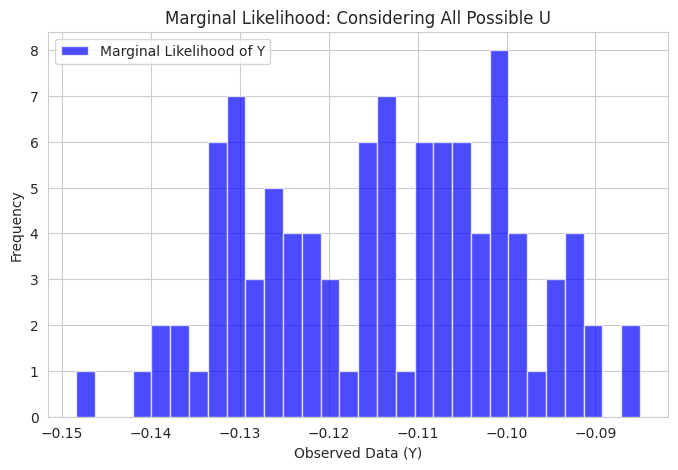

In [1]:
# Simulating Y as a combination of features (F) multiplied by weights (U)

# Define parameters
num_features = 3  # Number of features in F
num_samples = 100  # Number of observations

# Generate feature matrix F (randomly sampled)
F = np.random.randn(num_samples, num_features)

# Define a prior for U (weights)
U_mean = np.zeros(num_features)  # Mean of the prior
U_cov = np.eye(num_features)  # Identity covariance (independent priors)

# Sample possible values of U from the prior
U_samples = np.random.multivariate_normal(U_mean, U_cov, size=1000)

# Generate observed data Y for each sampled U
Y_samples = []
for U in U_samples:
    noise = np.random.normal(0, 0.5, num_samples)  # Add Gaussian noise
    Y = F @ U + noise  # Model: Y = F * U + noise
    Y_samples.append(Y)

# Compute the marginal likelihood by averaging over all sampled U
Y_marginal_likelihood = np.mean(Y_samples, axis=0)

# Visualize the results
plt.figure(figsize=(8, 5))
plt.hist(Y_marginal_likelihood, bins=30, alpha=0.7, color='b', label="Marginal Likelihood of Y")
plt.xlabel("Observed Data (Y)")
plt.ylabel("Frequency")
plt.title("Marginal Likelihood: Considering All Possible Weights U")
plt.legend()
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# Define parameters
num_synergies = 3  # Number of latent synergies (dim of U)
num_muscles = 5  # Number of observed dimensions (dim of Y)
num_samples = 100  # Number of trials

np.random.seed(42)

# Define different F structures
F_full_rank = np.random.randn(num_muscles, num_synergies)  # Full-rank, independent synergies
F_low_rank = np.random.randn(num_muscles, num_synergies)
F_low_rank[:, 2] = F_low_rank[:, 0] + F_low_rank[:, 1]  # Making one column redundant

F_correlated = np.array([[1, 0.9, 0.5], [0.9, 1, 0.7], [0.5, 0.7, 1]])  # Highly correlated synergies
F_correlated = np.vstack((F_correlated, np.random.randn(2, 3)))  # Extend to 5 muscles

# Define a standard Gaussian prior for U
G_U = np.eye(num_synergies)  # Independent prior covariance of U

# Compute covariance of Y for different F structures
G_Y_full_rank = F_full_rank @ G_U @ F_full_rank.T
G_Y_low_rank = F_low_rank @ G_U @ F_low_rank.T
G_Y_correlated = F_correlated @ G_U @ F_correlated.T

# Simulate Y samples for each case
Y_samples_full_rank = np.random.multivariate_normal(np.zeros(num_muscles), G_Y_full_rank, num_samples)
Y_samples_low_rank = np.random.multivariate_normal(np.zeros(num_muscles), G_Y_low_rank, num_samples)
Y_samples_correlated = np.random.multivariate_normal(np.zeros(num_muscles), G_Y_correlated, num_samples)

# Plot covariance matrices and sample distributions
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Covariance heatmaps
sns.heatmap(G_Y_full_rank, ax=axes[0, 0], cmap="coolwarm", annot=True)
axes[0, 0].set_title("G_Y (Full-Rank F)")

sns.heatmap(G_Y_low_rank, ax=axes[1, 0], cmap="coolwarm", annot=True)
axes[1, 0].set_title("G_Y (Low-Rank F)")

sns.heatmap(G_Y_correlated, ax=axes[2, 0], cmap="coolwarm", annot=True)
axes[2, 0].set_title("G_Y (Correlated F)")

# Sample distributions
axes[0, 1].scatter(Y_samples_full_rank[:, 0], Y_samples_full_rank[:, 1], alpha=0.5)
axes[0, 1].set_title("Y Samples (Full-Rank F)")

axes[1, 1].scatter(Y_samples_low_rank[:, 0], Y_samples_low_rank[:, 1], alpha=0.5)
axes[1, 1].set_title("Y Samples (Low-Rank F)")

axes[2, 1].scatter(Y_samples_correlated[:, 0], Y_samples_correlated[:, 1], alpha=0.5)
axes[2, 1].set_title("Y Samples (Correlated F)")

# Histograms of Y values for comparison
sns.histplot(Y_samples_full_rank[:, 0], ax=axes[0, 2], bins=20, kde=True, color="blue")
axes[0, 2].set_title("Y Distribution (Full-Rank F)")

sns.histplot(Y_samples_low_rank[:, 0], ax=axes[1, 2], bins=20, kde=True, color="blue")
axes[1, 2].set_title("Y Distribution (Low-Rank F)")

sns.histplot(Y_samples_correlated[:, 0], ax=axes[2, 2], bins=20, kde=True, color="blue")
axes[2, 2].set_title("Y Distribution (Correlated F)")

plt.tight_layout()
plt.show()
